In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.tsa.stattools as ts


In [3]:
day0 = pd.read_csv('../../datasets/round1/prices_round_1_day_-2.csv', sep=';')
day1 = pd.read_csv('../../datasets/round1/prices_round_1_day_-1.csv', sep=';')
day2 = pd.read_csv('../../datasets/round1/prices_round_1_day_0.csv', sep=';')

trades0 = pd.read_csv('../../datasets/round1/trades_round_1_day_-2.csv', sep=';')
trades1 = pd.read_csv('../../datasets/round1/trades_round_1_day_-1.csv', sep=';')
trades2 = pd.read_csv('../../datasets/round1/trades_round_1_day_0.csv', sep=';')

df = pd.concat([day0, day1, day2])
trades = pd.concat([trades0, trades1, trades2])

df.head()


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,NaN,NaN,NaN,10005.0,9.0,10008.0,17.0,NaN,NaN,9998.5,0.0
1,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,25.0,NaN,NaN,NaN,NaN,10010.0,0.0
2,-2,100,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,NaN,10006.0,11.0,10008.0,16.0,NaN,NaN,10000.5,0.0
3,-2,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10011.0,20.0,NaN,NaN,10000.0,0.0
4,-2,200,INTARIAN_PEPPER_ROOT,9995.0,12.0,NaN,NaN,NaN,NaN,10008.0,20.0,NaN,NaN,NaN,NaN,10001.5,0.0


In [17]:
trades.head()


,timestamp,symbol,currency,price,quantity
0,700,ASH_COATED_OSMIUM,XIRECS,9990.0,6
1,900,ASH_COATED_OSMIUM,XIRECS,9998.0,2
2,1000,INTARIAN_PEPPER_ROOT,XIRECS,9995.0,7
3,2500,ASH_COATED_OSMIUM,XIRECS,10011.0,8
4,4000,INTARIAN_PEPPER_ROOT,XIRECS,10007.0,7


In [6]:
df['best_bid'] = df[['bid_price_1', 'bid_price_2', 'bid_price_3']].max(axis=1)
df['best_ask'] = df[['ask_price_1', 'ask_price_2', 'ask_price_3']].min(axis=1)
df['lowest_bid'] = df[['bid_price_1', 'bid_price_2', 'bid_price_3']].min(axis=1)


In [7]:
df['mid_price = (best_bid + best_ask) / 2'] = np.where(df['mid_price'] == (df['best_bid']+df['best_ask'])/2, 1, 0)
df['mid_price = (lowest_bid + best_ask) / 2'] = np.where(df['mid_price'] == (df['lowest_bid']+df['best_ask'])/2, 1, 0)

df.head()


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,...,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,best_bid,best_ask,lowest_bid,mid_price = (best_bid + best_ask) / 2,mid_price = (lowest_bid + best_ask) / 2
0,-2,0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,NaN,NaN,NaN,10005.0,...,17.0,NaN,NaN,9998.5,0.0,9992.0,10005.0,9992.0,1,1
1,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,...,NaN,NaN,NaN,10010.0,0.0,NaN,10010.0,NaN,0,0
2,-2,100,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,NaN,10006.0,...,16.0,NaN,NaN,10000.5,0.0,9995.0,10006.0,9992.0,1,0
3,-2,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,...,20.0,NaN,NaN,10000.0,0.0,9992.0,10008.0,9992.0,1,1
4,-2,200,INTARIAN_PEPPER_ROOT,9995.0,12.0,NaN,NaN,NaN,NaN,10008.0,...,NaN,NaN,NaN,10001.5,0.0,9995.0,10008.0,9995.0,1,1


In [8]:
df.drop(['mid_price = (best_bid + best_ask) / 2', 'mid_price = (lowest_bid + best_ask) / 2', 'day'], axis=1, inplace=True)
trades.drop(['buyer', 'seller'], axis=1, inplace=True)


In [9]:
ash = df.loc[df['product'] == 'ASH_COATED_OSMIUM']
pepper = df.loc[df['product'] == 'INTARIAN_PEPPER_ROOT']

ash.head()


,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,best_bid,best_ask,lowest_bid
1,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,25.0,NaN,NaN,NaN,NaN,10010.0,0.0,NaN,10010.0,NaN
3,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10011.0,20.0,NaN,NaN,10000.0,0.0,9992.0,10008.0,9992.0
5,200,ASH_COATED_OSMIUM,9992.0,15.0,9989.0,30.0,NaN,NaN,10008.0,15.0,10010.0,30.0,NaN,NaN,10000.0,0.0,9992.0,10008.0,9989.0
6,300,ASH_COATED_OSMIUM,9992.0,13.0,9989.0,26.0,NaN,NaN,10008.0,13.0,10010.0,26.0,NaN,NaN,10000.0,0.0,9992.0,10008.0,9989.0
8,400,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10010.0,20.0,NaN,NaN,10000.0,0.0,9992.0,10008.0,9992.0


In [11]:
ash_trades = trades.loc[trades['symbol'] == 'ASH_COATED_OSMIUM']
ash_trades.head()


,timestamp,symbol,currency,price,quantity
0,700,ASH_COATED_OSMIUM,XIRECS,9990.0,6
1,900,ASH_COATED_OSMIUM,XIRECS,9998.0,2
3,2500,ASH_COATED_OSMIUM,XIRECS,10011.0,8
5,6100,ASH_COATED_OSMIUM,XIRECS,10013.0,8
8,12900,ASH_COATED_OSMIUM,XIRECS,10001.0,9


In [63]:
ash = ash.assign(timestamp=[i for i in range(len(ash))])
pepper = pepper.assign(timestamp=[i for i in range(len(pepper))])

ash.set_index('timestamp')
pepper.set_index('timestamp')


,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,best_bid,best_ask,lowest_bid
timestamp,,,,,,,,,,,,,,,,,,
0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,NaN,NaN,NaN,10005.0,9.0,10008.0,17.0,NaN,NaN,9998.5,0.0,9992.0,10005.0,9992.0
1,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,NaN,10006.0,11.0,10008.0,16.0,NaN,NaN,10000.5,0.0,9995.0,10006.0,9992.0
2,INTARIAN_PEPPER_ROOT,9995.0,12.0,NaN,NaN,NaN,NaN,10008.0,20.0,NaN,NaN,NaN,NaN,10001.5,0.0,9995.0,10008.0,9995.0
3,INTARIAN_PEPPER_ROOT,NaN,NaN,NaN,NaN,NaN,NaN,10006.0,10.0,10008.0,21.0,NaN,NaN,10006.0,0.0,NaN,10006.0,NaN
4,INTARIAN_PEPPER_ROOT,9992.0,20.0,NaN,NaN,NaN,NaN,10006.0,12.0,10008.0,20.0,NaN,NaN,9999.0,0.0,9992.0,10006.0,9992.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,INTARIAN_PEPPER_ROOT,12989.0,19.0,NaN,NaN,NaN,NaN,13006.0,12.0,NaN,NaN,NaN,NaN,12997.5,0.0,12989.0,13006.0,12989.0
29996,INTARIAN_PEPPER_ROOT,12993.0,8.0,NaN,NaN,NaN,NaN,13007.0,8.0,13010.0,25.0,NaN,NaN,13000.0,0.0,12993.0,13007.0,12993.0
29997,INTARIAN_PEPPER_ROOT,12989.0,20.0,NaN,NaN,NaN,NaN,13007.0,10.0,13010.0,20.0,NaN,NaN,12998.0,0.0,12989.0,13007.0,12989.0


In [14]:
ash_trades = ash_trades.assign(timestamp=ash_trades['timestamp'] // 100 - 1)
ash_trades.head()


,timestamp,symbol,currency,price,quantity
0,6,ASH_COATED_OSMIUM,XIRECS,9990.0,6
1,8,ASH_COATED_OSMIUM,XIRECS,9998.0,2
3,24,ASH_COATED_OSMIUM,XIRECS,10011.0,8
5,60,ASH_COATED_OSMIUM,XIRECS,10013.0,8
8,128,ASH_COATED_OSMIUM,XIRECS,10001.0,9


In [19]:
cols = ['mid_price', 'best_bid', 'best_ask']
for col in cols:
    ash[col] = ash[col].ffill()
    pepper[col] = pepper[col].ffill()


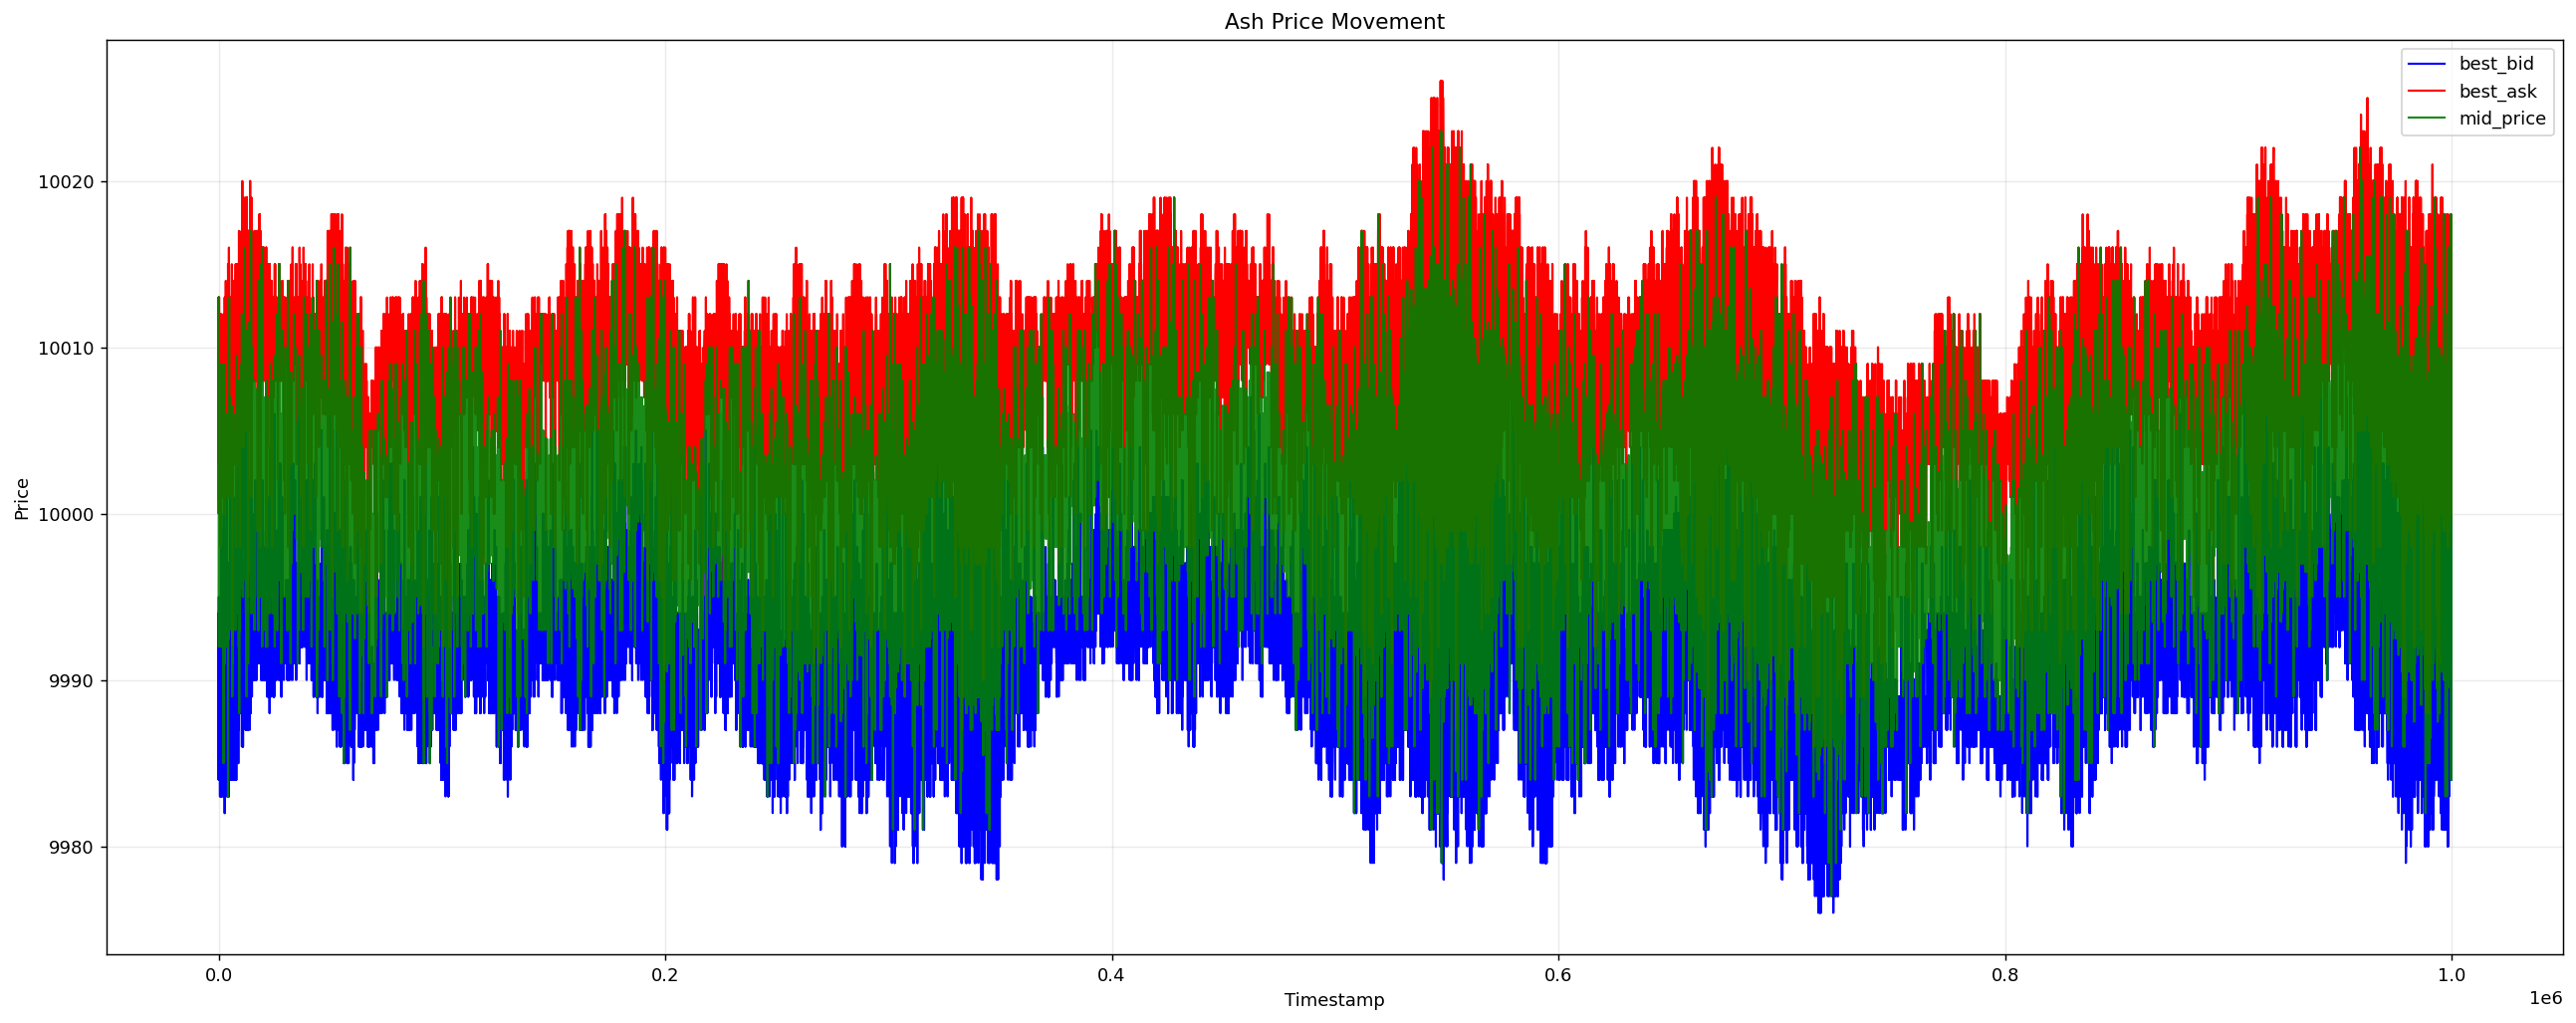

In [20]:
pa = ash[['timestamp'] + cols].copy().sort_values('timestamp')
pa[cols] = pa[cols].replace(0, np.nan).ffill()
pa['mid_price_ewma'] = pa['mid_price'].ewm(span=10000).mean()
# pa = pa.iloc[::5]

fig, ax = plt.subplots(figsize=(20, 8), dpi=130)
ax.plot(pa['timestamp'], pa['best_bid'], label='best_bid', color='blue', linewidth=1.2)
ax.plot(pa['timestamp'], pa['best_ask'], label='best_ask', color='red', linewidth=1.2)
ax.plot(pa['timestamp'], pa['mid_price'], label='mid_price', color='green', linewidth=1.2, alpha=0.9)

ax.set_xlabel('Timestamp')
ax.set_ylabel('Price')
ax.set_title('Ash Price Movement')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# filter large trades
large_trades = ash_trades[ash_trades['quantity'] >= 6].copy()

# determine trade direction
def trade_direction(row):
    


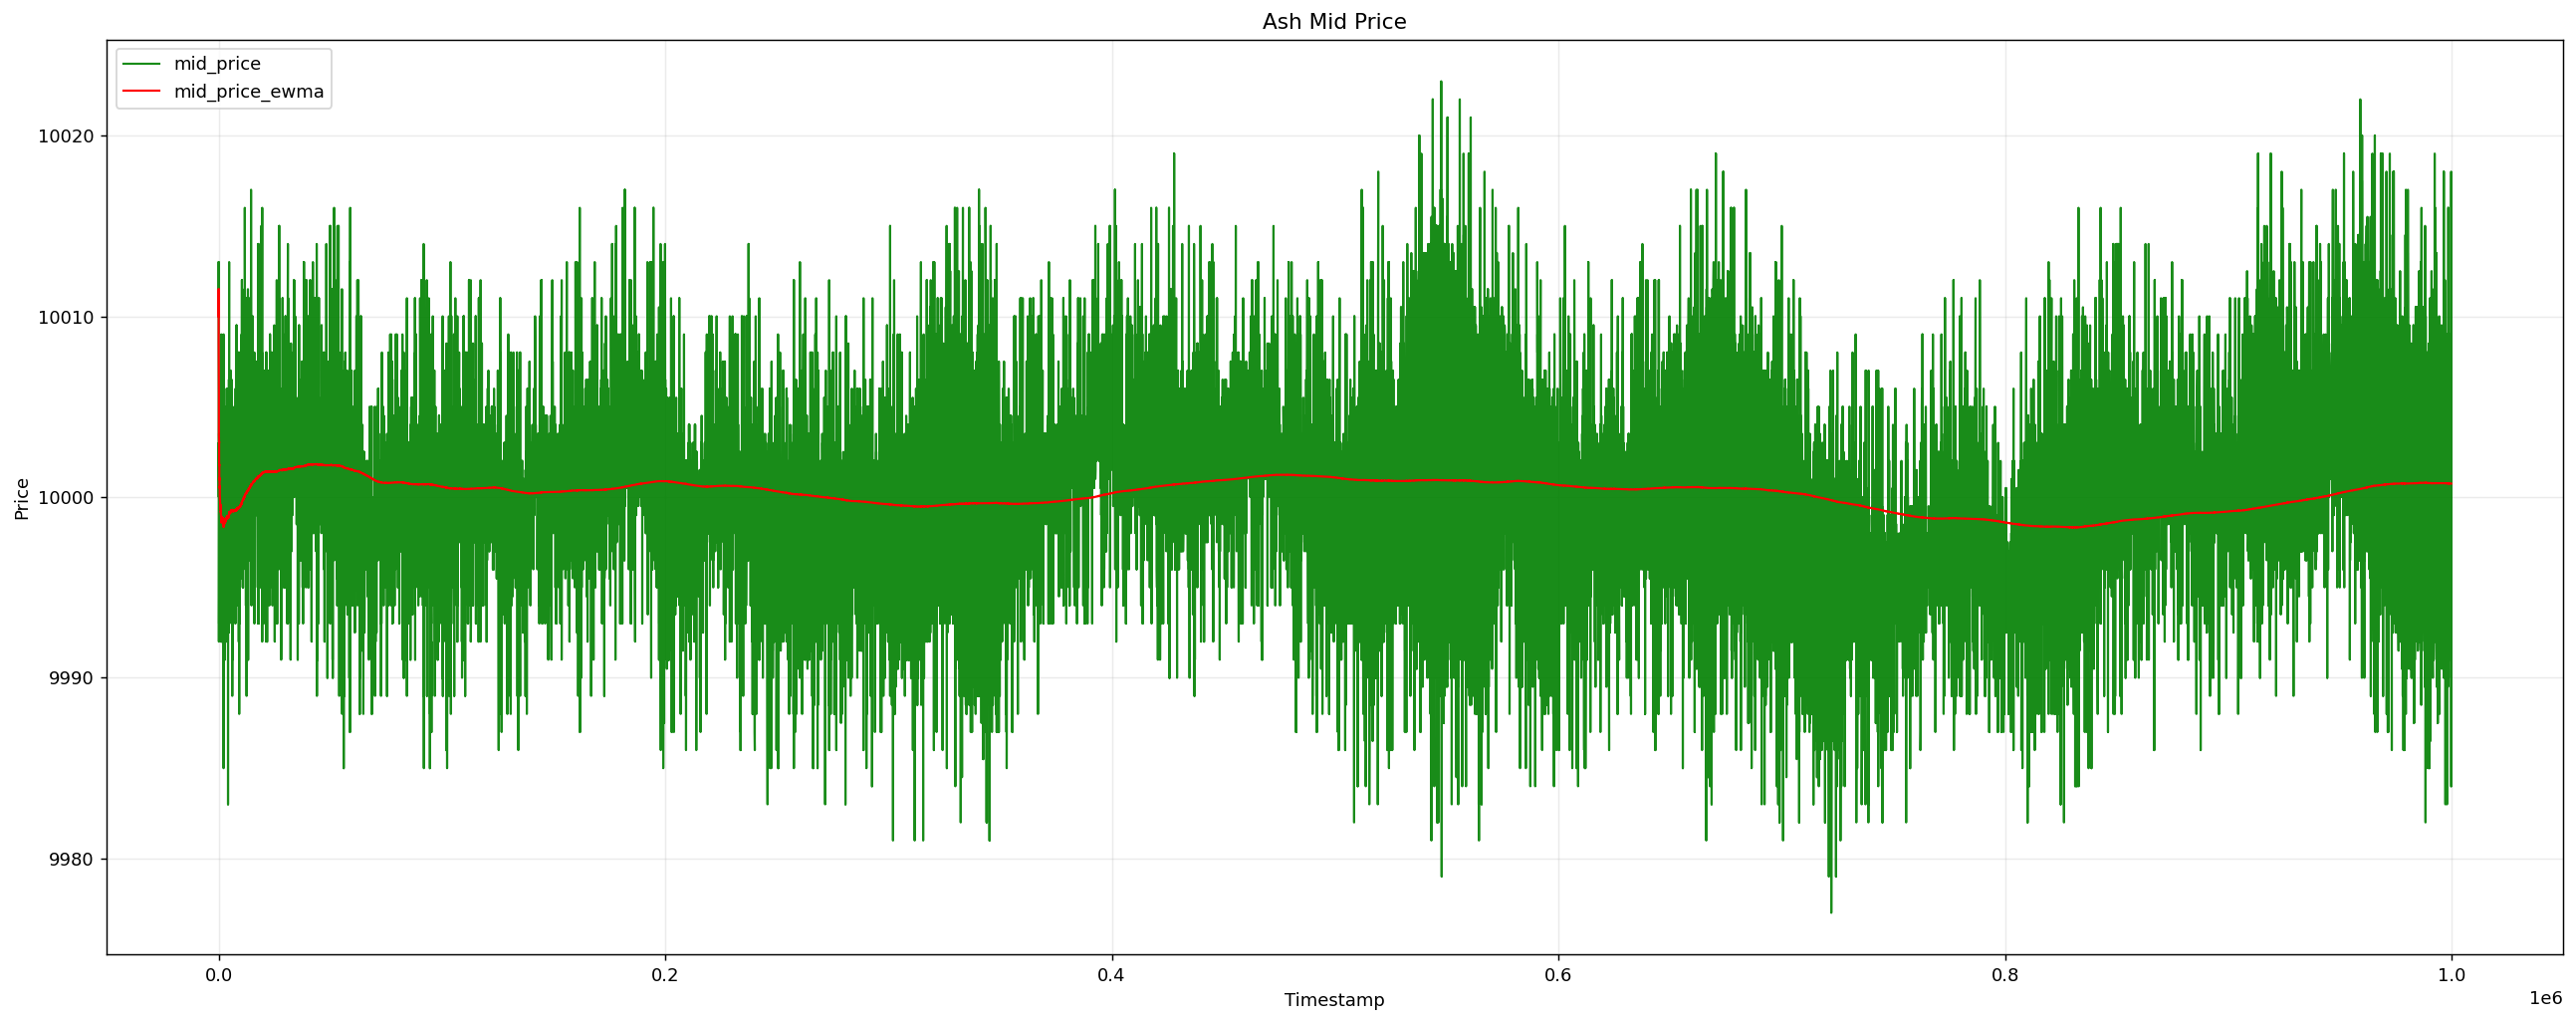

In [21]:
fig, ax = plt.subplots(figsize=(20, 8), dpi=130)
ax.plot(pa['timestamp'], pa['mid_price'], label='mid_price', color='green', linewidth=1.2, alpha=0.9)
ax.plot(pa['timestamp'], pa['mid_price_ewma'], label='mid_price_ewma', color='red', linewidth=1.2)

ax.set_xlabel('Timestamp')
ax.set_ylabel('Price')
ax.set_title('Ash Mid Price')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


### Pepper Visual

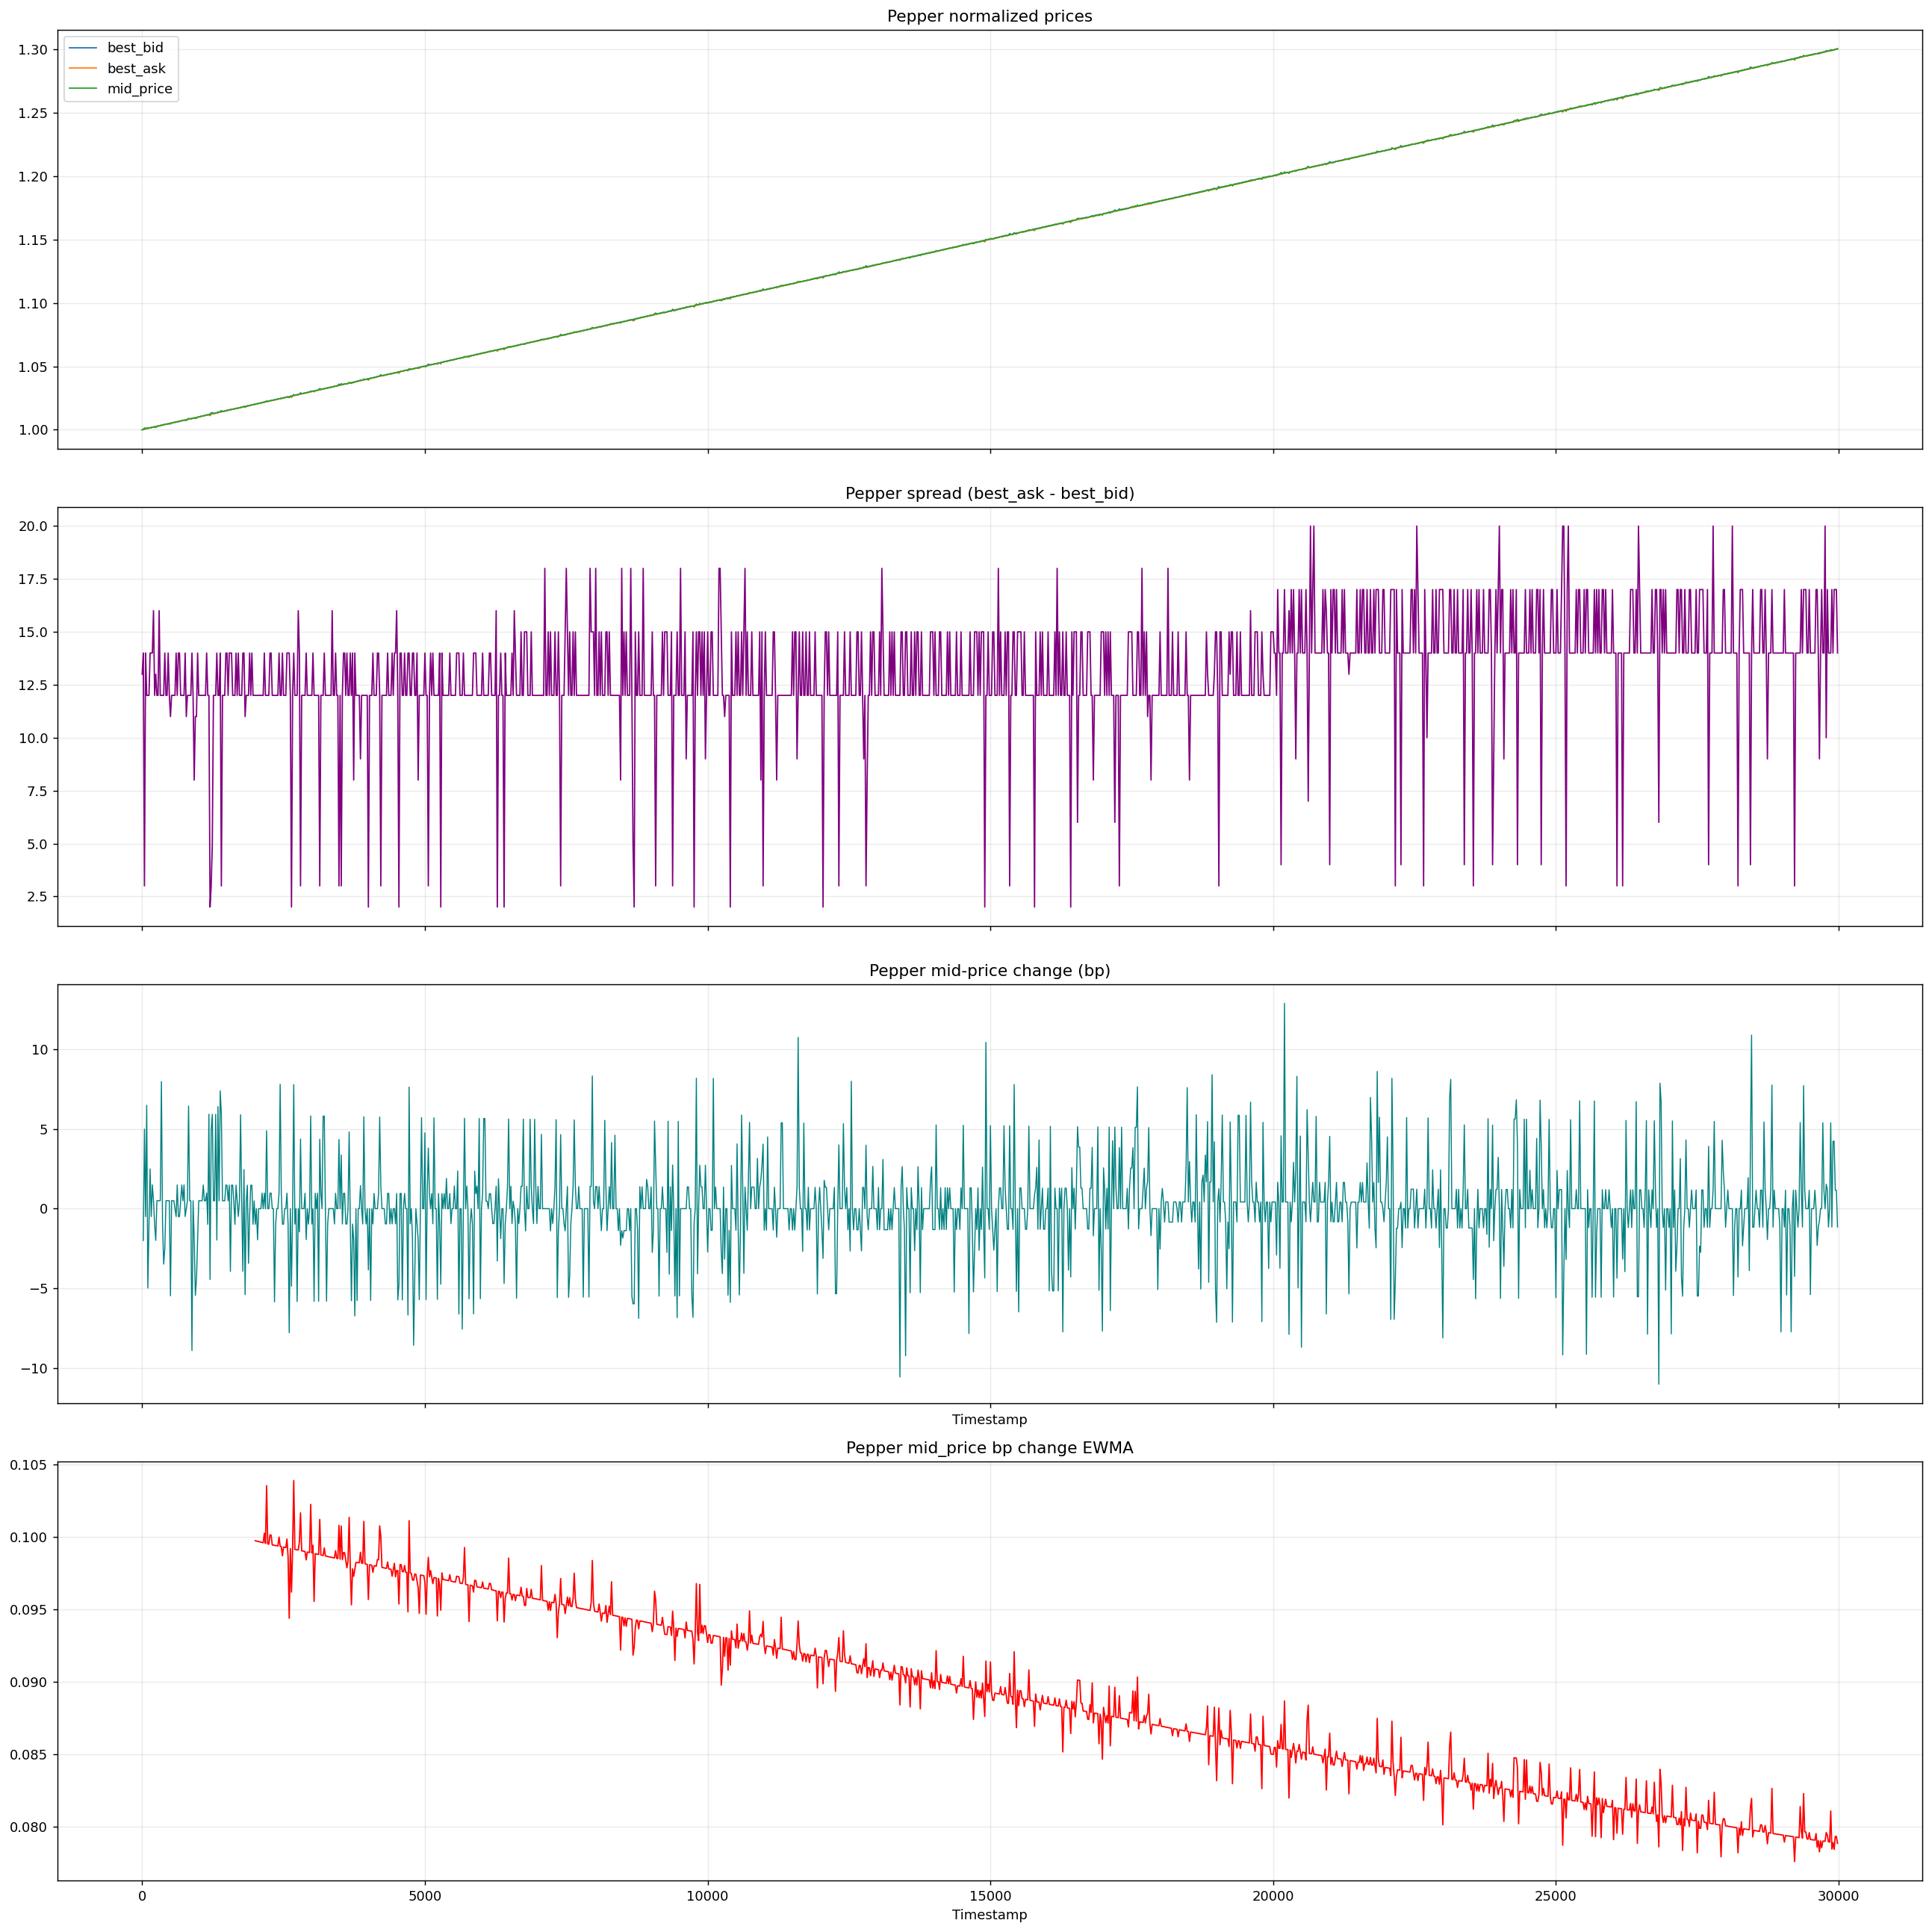

In [137]:
pp = pepper[['timestamp'] + cols].copy().sort_values('timestamp').reset_index(drop=True)
pp[cols] = pp[cols].replace(0, np.nan).ffill()

pp['spread'] = pp['best_ask'] - pp['best_bid']
pp['mid_ret_bp'] = pp['mid_price'].pct_change() * 1e4
pp['mid_bp_ewma'] = pp['mid_ret_bp'].ewm(span=5000).mean()
pp = pp.iloc[::20]

fig, ax = plt.subplots(4, 1, figsize=(20, 20), dpi=130, sharex=True)

base = pp[['best_bid', 'best_ask', 'mid_price']].iloc[0]

x = pp['timestamp'].to_numpy()
ax[0].plot(x, (pp['best_bid'] / base['best_bid']).to_numpy(), label='best_bid', lw=1.0)
ax[0].plot(x, (pp['best_ask'] / base['best_ask']).to_numpy(), label='best_ask', lw=1.0)
ax[0].plot(x, (pp['mid_price'] / base['mid_price']).to_numpy(), label='mid_price', lw=1.0)
ax[0].set_title('Pepper normalized prices')
ax[0].grid(alpha=0.25)
ax[0].legend()

ax[1].plot(x, pp['spread'].to_numpy(), color='purple', lw=1.0)
ax[1].set_title('Pepper spread (best_ask - best_bid)')
ax[1].grid(alpha=0.25)

ax[2].plot(x, pp['mid_ret_bp'].to_numpy(), color='teal', lw=0.8)
ax[2].set_title('Pepper mid-price change (bp)')
ax[2].set_xlabel('Timestamp')
ax[2].grid(alpha=0.25)

ax[3].plot(x[100:], pp['mid_bp_ewma'].to_numpy()[100:], color='red', lw=1.0)
ax[3].set_title('Pepper mid_price bp change EWMA')
ax[3].set_xlabel('Timestamp')
ax[3].grid(alpha=0.25)

plt.tight_layout()
plt.show()
